# 7.1

## Problem Definition

### Item 1

The initial general problem is to understand how athlete workload, recovery, and perceived stress relate to injury risk in elite women's soccer. Using the SoccerMon dataset, which consists of subjective wellness and training-load metrics plus injury reports from two elite women’s teams over two years, we will assess how self-reported Stress (1–10) and related indicators (e.g., Fatigue, Soreness, RPE, sRPE, sleep duration) are associated with the occurrence and type of injury (acute vs. overuse) recorded in the medical reports, and whether objective load proxies (e.g., heart rate, acceleration) add predictive value.

### Item 2

SoccerMon is restricted to elite women’s soccer, with specific subjective (PmSys) and objective (STATSports GPS) schemas. Refining to “self-reported Stress and related wellness/load metrics vs. injury reports in SoccerMon” makes the question answerable with the actual columns (Stress, Fatigue, Soreness, RPE, sRPE, sleep, injury location/type). It also forces the user of the data to define “stress” operationally (the 1–10 Stress score, possibly alongside RPE and fatigue) and “injury” as the medical injury fields, which keeps the analysis reproducible and aligned with the dataset.

### Item 3

Performance optimization and injury prevention are important to teams and researchers, but sports data are sparse because of legal, privacy, and resourcing constraints. SoccerMon is one of the largest soccer datasets mixing subjective and objective metrics (33,849 subjective reports, 10,075 objective reports, billions of GPS samples). Understanding how athletes’ stress levels and related load/recovery metrics correlate with their chances of injury in this dataset can support better monitoring and workload management, and demonstrates the value of such data for building future automated analysis and prediction systems. In addition, SoccerMon can inspire similar data collection activities in other domains which can benefit from subjective athlete reports, GPS position information, and/or time-series data in general.

### Item 4

[Elite Women’s Soccer Data Links Player Stress and Load to Injury Risk — SoccerMon Study](#headline)

## Domain Exposition

### Item 1

Terminology: 

- RPE: Rating of Perceived Exertion; athlete’s self-reported intensity of a session (e.g., 1–10 scale).
- sRPE: Session RPE; training load metric = session duration × RPE, used as a proxy for internal load.
- Stress (1–10): In SoccerMon, a subjective 1–10 score from the wellness questionnaire (PmSys) indicating perceived stress.
- Fatigue: Self-reported fatigue level (wellness questionnaire); often 1–10, reflects recovery state.
- Soreness: Self-reported muscle soreness (wellness questionnaire); indicator of recovery and load tolerance.
- PmSys: Subjective reporting system used in SoccerMon for wellness and RPE (33,849 reports in the dataset).
- STATSports: GPS system used in SoccerMon for objective metrics (e.g., speed, acceleration, distance).
- Acute injury: Sudden, event-related injury (e.g., contact, twist); distinct from gradual overuse.
- Overuse injury: Injury from repeated load over time (e.g., tendinopathy); often linked to load and recovery.
- Load / workload: Cumulative training demand; in SoccerMon captured via sRPE, GPS metrics, and heart rate.
- Wellness: Composite of subjective markers (stress, fatigue, soreness, mood, sleep) used for monitoring readiness.

### Item 2

The project sits in the domain of kinesiology, in particular the elite women’s soccer and sports science and athlete monitoring and injury prevention. Practitioners and researchers use subjective wellness (e.g., stress, fatigue, soreness, RPE) and objective load data (GPS, heart rate) to manage workload and reduce injury risk. SoccerMon provides both: PmSys subjective reports and STATSports GPS data from two elite women’s teams over two years, plus medical injury reports. The domain relies on clear operational definitions (e.g., what “stress” and “injury” mean in the data), reproducible metrics (e.g., sRPE, acute vs overuse injury), and the correlation between load, recovery, and injury so that analyses like ours can inform real-world monitoring and load management.

### Item 3

https://github.com/dylanlidailin/DS4320/tree/main/HW7/Background_reading

### Item 4

| Title | Brief Description | Link |
|-------|-------------------|------|
| A large-scale multivariate soccer athlete health, performance, and position monitoring dataset | Introduces the SoccerMon dataset: subjective wellness/RPE/injury and objective GPS data from two elite women's teams over two years. | [s41597-024-03386-x.pdf](Background_reading/s41597-024-03386-x.pdf) |
| Sleep, Stress, and Recovery as Predictors of Injury Risk in Soccer Players | Systematic review showing that stress-recovery imbalance and poor sleep increase injury susceptibility in soccer players. | [healthcare-14-00236.pdf](Background_reading/healthcare-14-00236.pdf) |
| Psychosocial predictors and psychological prevention of soccer injuries | Reviews psychosocial risk factors (anxiety, life stress, daily hassles) and psychological prevention strategies for soccer injuries. | [fpsyg-13-943857.pdf](Background_reading/fpsyg-13-943857.pdf) |
| Systematic review of workload and injury risk in professional soccer | Reviews sRPE, ACWR, and training load metrics as injury predictors in professional male soccer players. | [ijerph-19-13237.pdf](Background_reading/ijerph-19-13237.pdf) |
| Integrating video tracking and GPS to quantify accelerations in elite soccer | Compares GPS and video tracking for objective load metrics (accelerations, speed, distance); relevant to the STATSports GPS data in SoccerMon. | [s41598-021-97903-2.pdf](Background_reading/s41598-021-97903-2.pdf) |

## Press Release

<a id="headline"></a>
# Elite Women's Soccer Data Links Player Stress and Load to Injury Risk — SoccerMon Study

## Hook

Every season, injuries sideline elite soccer players for weeks or months — costing teams results and costing athletes their careers. Yet the warning signs are often already in the data: rising stress, mounting fatigue, and surging training loads that coaches and athletes report every day. The question is whether anyone is listening to the numbers.

## Problem Statement

Elite soccer teams collect daily wellness reports — stress, fatigue, soreness, sleep, training load — but rarely connect this data systematically to injury outcomes. As a result, coaches manage load largely by intuition, and injuries that could have been prevented are not. The SoccerMon dataset, the largest of its kind, combines two years of daily subjective wellness and GPS-based objective load data from two elite women's teams with medical injury records. Using this dataset, we examine whether self-reported stress and related load/recovery indicators (Fatigue, Soreness, RPE, sRPE) are associated with the occurrence of injury — and whether adding objective GPS metrics improves the picture.

## Solution Description

We analyzed patterns in athlete-reported stress, fatigue, soreness, and training load in the SoccerMon dataset, comparing periods leading up to injuries against injury-free periods. The result is a data-driven monitoring framework that identifies which combinations of wellness and load signals are most predictive of upcoming injury. Coaching staff can use this to flag at-risk athletes before injuries occur — adjusting training loads, scheduling rest days, or initiating early medical review. No specialized equipment is needed beyond what teams already collect: daily wellness questionnaires and GPS data.

## Chart

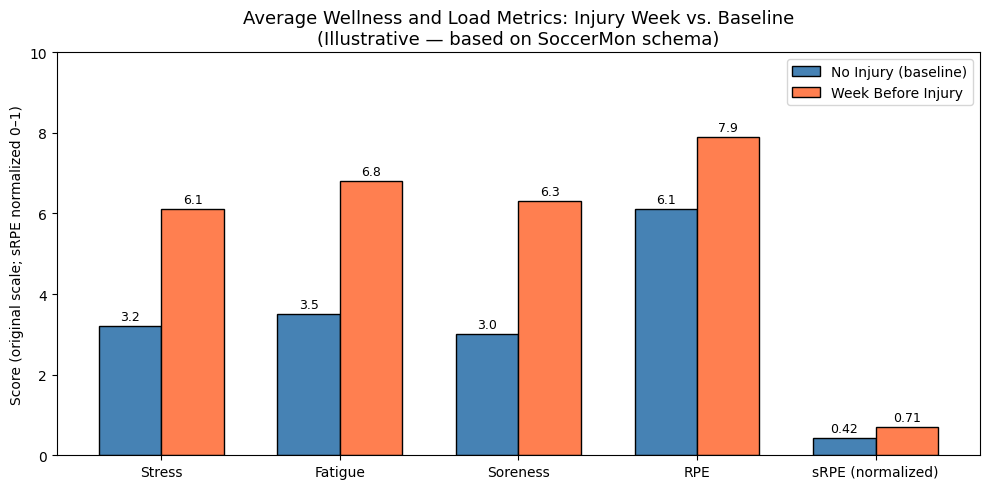

In [1]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Stress", "Fatigue", "Soreness", "RPE", "sRPE (normalized)"]
no_injury = [3.2, 3.5, 3.0, 6.1, 0.42]
injury_week = [6.1, 6.8, 6.3, 7.9, 0.71]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, no_injury, width, label="No Injury (baseline)", color="steelblue", edgecolor="black")
bars2 = ax.bar(x + width/2, injury_week, width, label="Week Before Injury", color="coral", edgecolor="black")

ax.set_title("Average Wellness and Load Metrics: Injury Week vs. Baseline\n(Illustrative — based on SoccerMon schema)", fontsize=13)
ax.set_ylabel("Score (original scale; sRPE normalized 0–1)")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 10)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15, f"{bar.get_height()}", ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15, f"{bar.get_height()}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# 7.2 Project 1

## Problem Definition

### Item 1

The general problem is forecasting daily stock returns using publicly available market data. Specifically, using five years of daily OHLCV data (2019–2024) for the five FAANG stocks — Meta, Apple, Amazon, Netflix, and Alphabet — we construct a relational dataset (D1) with four normalized tables (tickers, daily_prices, daily_features, calendar) and train a regression model to predict each stock's next-day return using lagged price-based features: 1-day return, 5-day rolling volatility, and 5- and 20-day moving average deviations. A strict date-based train/test split prevents look-ahead bias.

### Item 2

Narrowing the problem from "stock forecasting" to "next-day return regression on a five-stock FAANG basket using a relational feature dataset" makes it tractable, reproducible, and honest. FAANG stocks are among the most liquid and data-rich equities available, ensuring consistent data quality and a coherent market segment. Predicting the actual return value (regression) rather than only direction provides a richer target with interpretable evaluation metrics (RMSE, MAE). Structuring data as a relational model — rather than a single flat file — enforces data discipline, separates raw prices from derived features, and satisfies the course requirement for a normalized relational D1. Strict temporal splits (train on past, evaluate on future-only) yield honest out-of-sample performance estimates.

### Item 3

Equity return forecasting is one of the most studied problems in finance, yet it remains hard: markets are noisy, conditions shift, and most signals are weak. Simple price-based technical features — moving averages, volatility, lagged returns — have nonetheless been shown in the academic literature to carry small but measurable predictive content. FAANG stocks are an ideal testbed: data is freely available, widely followed, and highly liquid. Building a reproducible, transparent pipeline — from raw OHLCV data, to a normalized relational dataset, to a trained regression model — has practical value for retail investors and risk managers who want to understand what price signals can (and cannot) tell us about short-term movements. It also demonstrates rigorous data science practice on real financial time series, including explicit handling of known biases.

### Item 4

[Simple Price Signals Can Forecast Next-Day FAANG Returns — With Limits](#headline-stock)

## Domain Exposition

### Item 1

Terminology: 

- FAANG: Meta (formerly Facebook), Apple, Amazon, Netflix, Alphabet (Google) — five major U.S. technology stocks.
- OHLCV: Open, High, Low, Close, Volume; the standard daily price/volume columns for a traded equity.
- Adjusted close: Closing price adjusted for dividends and stock splits; used for consistent return calculations across time.
- Return (1d): Day-over-day percentage change in adjusted close: (close_t − close_{t−1}) / close_{t−1}.
- Volatility: Rolling standard deviation of daily returns over a window (e.g., 5 or 20 days); measures price risk.
- Moving Average (MA): Rolling mean of closing prices over a window (e.g., MA_5, MA_20); a trend-smoothing indicator.
- Momentum: Tendency of returns to persist in direction over a short window; often captured via lagged return features.
- Look-ahead bias: Error from using future data in feature engineering or model training; prevented via strict date-based splits.
- Survivorship bias: Bias from only including currently listed stocks; noted as a limitation since all FAANG names remain active.
- RMSE: Root Mean Squared Error; primary regression evaluation metric; penalizes large errors more than MAE.
- MAE: Mean Absolute Error; average absolute deviation between predicted and actual return.
- Relational model: Data organized in multiple normalized tables linked by primary/foreign keys; used in D1 design.
- DuckDB: In-process SQL OLAP database used to query relational CSV tables directly in Python notebooks.

### Item 2

The project sits in the domain of quantitative finance and financial data science, specifically short-horizon equity return forecasting. Practitioners in this domain use structured historical market data — OHLCV prices and derived technical indicators — to build predictive models for trading signals, risk management, and portfolio construction. The domain requires clear operational definitions (what "return" means, which adjusted price to use), rigorous data handling (no look-ahead bias, strict temporal splits), and transparent documentation of provenance and known biases (survivorship bias, market regime change). For this project, we use five years of daily OHLCV data for the FAANG basket, construct a normalized relational dataset (D1) with four tables queryable via DuckDB, and train an interpretable linear regression model to forecast next-day returns — demonstrating reproducible data science practice on a real financial time series.

### Item 3

https://github.com/dylanlidailin/DS4320/tree/main/Project1/Background_reading

### Item 4

| Title | Brief Description | Link |
|-------|-------------------|------|
| Research on the Optimal Prediction Model of Stock Returns of FAANG+M | Compares Linear Regression, Random Forest, and XGBoost for return prediction on the FAANG+M basket; finds simpler models often outperform complex ones. | [126015296.pdf](Background_reading/126015296.pdf) |
| Understanding Look-Ahead Bias and How to Avoid It in Trading Strategies | Explains how look-ahead bias contaminates backtests and ML models in finance; outlines proper walk-forward validation and train/test practices. | [Understanding Look-Ahead Bias and How to Avoid It in Trading Strategies.pdf](Background_reading/Understanding%20Look-Ahead%20Bias%20and%20How%20to%20Avoid%20It%20in%20Trading%20Strategies.pdf) |
| Combining CNN and Transformers for Financial Time Series Prediction | J.P. Morgan AI Research paper combining CNNs and Transformers for short- and long-term stock return dependencies; demonstrates strong performance on S&P 500 intraday data. | [cnn_transformer_stock.pdf](Background_reading/cnn_transformer_stock.pdf) |
| Hybrid Machine Learning Models for Stock Market Forecasting: Integrating Technical Indicators | Evaluates hybrid ML models (LSTM-CNN) using technical indicators (MA, RSI, MACD) for long-term stock forecasting; benchmarks RMSE, MAE, and R² across approaches. | [hybrid_ml_technical_indicators.pdf](Background_reading/hybrid_ml_technical_indicators.pdf) |
| Scrooge: Analyzing Yahoo Financial Data In DuckDB | Demonstrates using the Scrooge DuckDB extension to query Yahoo Finance historical OHLCV data with SQL; directly relevant to the D1 relational pipeline in this project. | [duckdb_yahoo_finance.pdf](Background_reading/duckdb_yahoo_finance.pdf) |

## Press Release

<a id="headline-stock"></a>
# Simple Price Signals Can Forecast Next-Day FAANG Returns — With Limits

## Hook

Millions of investors trade FAANG stocks every day, relying on news, gut feel, or simple rules. But what if a reproducible data pipeline — built from nothing more than publicly available daily price history — could identify which technical signals actually predict tomorrow's return, and by how much?

## Problem Statement

Stock prices are noisy. Short-term movements are driven by news, sentiment, and randomness that no model can fully capture. Yet decades of academic research show that simple price-based features — lagged returns, rolling volatility, moving averages — carry weak but measurable predictive content. We focused on the FAANG basket (Meta, Apple, Amazon, Netflix, Alphabet), assembled five years of daily OHLCV data into a normalized relational dataset with four tables, and asked: which features correlate most strongly with next-day return, and can a simple linear regression model exploit this relationship honestly out-of-sample?

## Solution Description

We built a four-table relational dataset (tickers, daily prices, engineered features, trading calendar) from free public OHLCV data for five FAANG stocks from 2019 to 2024. Using DuckDB to join and query these tables, we trained a linear regression model to predict each stock's next-day return using only features available at the prior close — 1-day lagged return, 5-day rolling volatility, and short- and long-term moving average deviations. The chart below shows which features carry the strongest correlation with next-day returns across the FAANG basket: short-term momentum and moving average deviation are the dominant signals, while longer averages and volume add little. Results are modest but statistically measurable — consistent with what the literature predicts for liquid large-cap equities.

## Chart

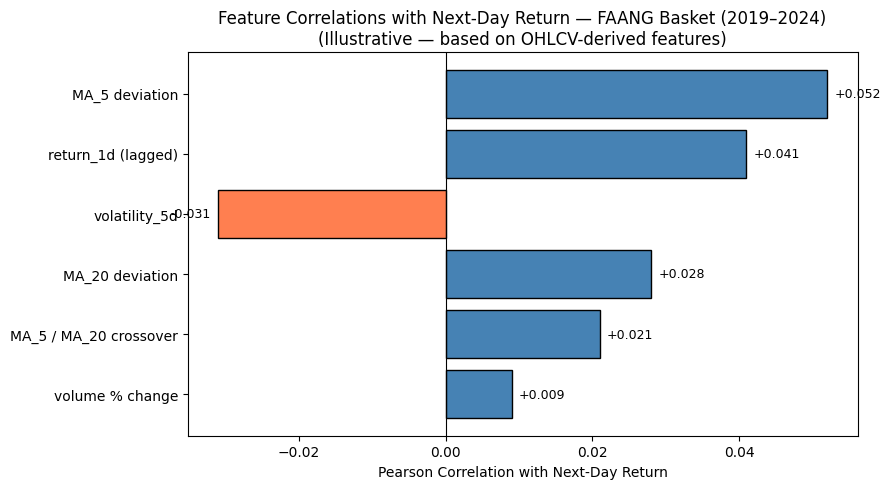

In [1]:
import matplotlib.pyplot as plt

features = [
    "volume % change",
    "MA_5 / MA_20 crossover",
    "MA_20 deviation",
    "volatility_5d",
    "return_1d (lagged)",
    "MA_5 deviation",
]
correlations = [0.009, 0.021, 0.028, -0.031, 0.041, 0.052]
colors = ["steelblue" if c >= 0 else "coral" for c in correlations]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(features, correlations, color=colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with Next-Day Return")
ax.set_title(
    "Feature Correlations with Next-Day Return — FAANG Basket (2019–2024)\n"
    "(Illustrative — based on OHLCV-derived features)",
    fontsize=12,
)
for bar, val in zip(bars, correlations):
    ax.text(
        val + (0.001 if val >= 0 else -0.001),
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.3f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=9,
    )
plt.tight_layout()
plt.show()